In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"arwaamohammed","key":"24e1c16aaca1cb50d23b5e933c290244"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:21<00:00, 16.9MB/s]



In [ ]:
!unzip -q intel-image-classification.zip -d intel_dataset

In [ ]:
import os

os.listdir("intel_dataset")

['seg_test', 'seg_train', 'seg_pred']

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from PIL import Image

In [ ]:
DATA_DIR = "intel_dataset"

TRAIN_DIR = os.path.join(DATA_DIR, "seg_train", "seg_train")
TEST_DIR = os.path.join(DATA_DIR, "seg_test", "seg_test")
PRED_DIR = os.path.join(DATA_DIR, "seg_pred")

In [ ]:
classes = sorted(os.listdir(TRAIN_DIR))

print("Classes:")
for i, class_name in enumerate(classes):
    print(i, ":", class_name)

print("\nNumber of classes:", len(classes))

Classes:
0 : buildings
1 : forest
2 : glacier
3 : mountain
4 : sea
5 : street

Number of classes: 6


In [ ]:
class_counts = {}

for class_name in classes:
    class_path = os.path.join(TRAIN_DIR, class_name)
    class_counts[class_name] = len(os.listdir(class_path))

class_counts

{'buildings': 2191,
 'forest': 2271,
 'glacier': 2404,
 'mountain': 2512,
 'sea': 2274,
 'street': 2382}

In [ ]:
class_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Images"]
)

class_df

,Class,Number of Images
0,buildings,2191
1,forest,2271
2,glacier,2404
3,mountain,2512
4,sea,2274
5,street,2382


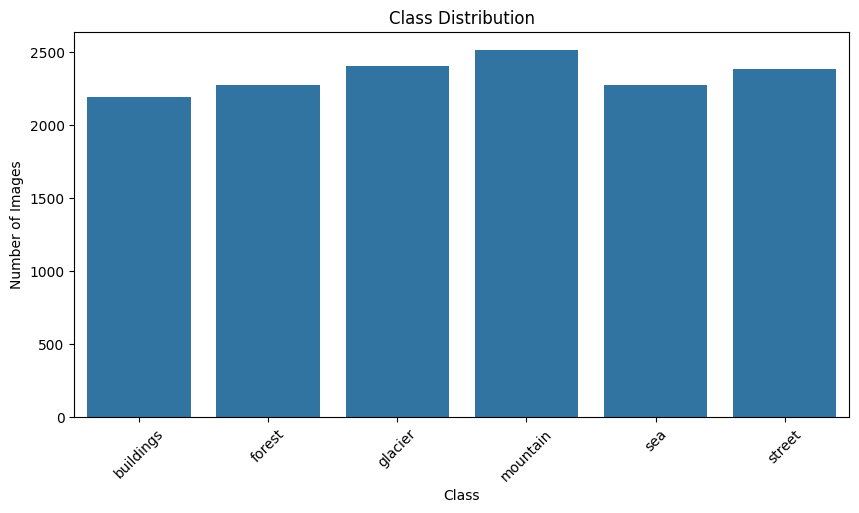

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(data=class_df,x="Class",y="Number of Images")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

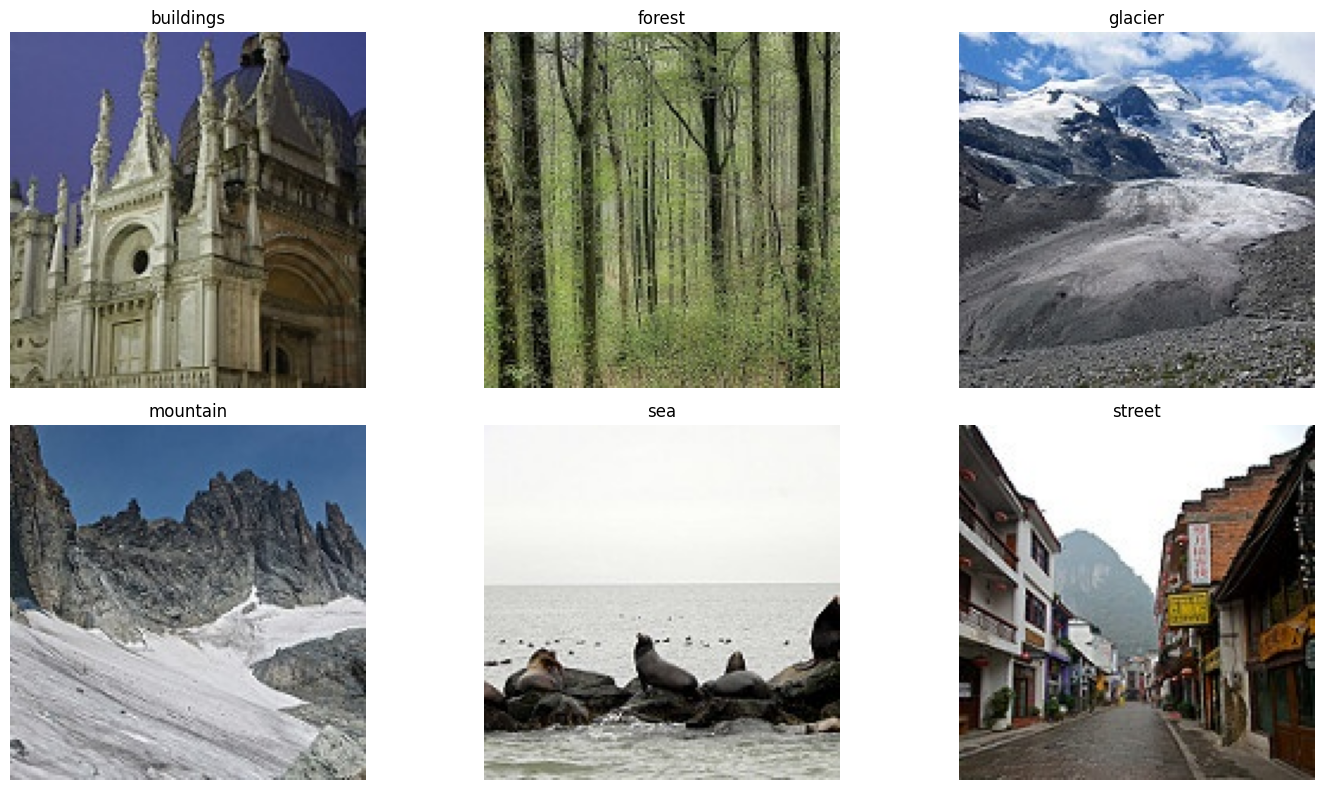

In [ ]:
plt.figure(figsize=(15, 8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(TRAIN_DIR, class_name)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
image_sizes = []

for class_name in classes:

    class_path = os.path.join(TRAIN_DIR, class_name)

    for image_name in os.listdir(class_path)[:100]:

        image_path = os.path.join(class_path, image_name)

        try:
            image = Image.open(image_path)
            image_sizes.append(image.size)

        except:
            pass

print("Number of images checked:", len(image_sizes))
print("Some image sizes:", image_sizes[:10])

Number of images checked: 600
Some image sizes: [(150, 150), (150, 150), (150, 150), (150, 150), (150, 150), (150, 150), (150, 150), (150, 150), (150, 150), (150, 150)]


In [ ]:
modes = {}

for class_name in classes:

    class_path = os.path.join(TRAIN_DIR, class_name)

    for image_name in os.listdir(class_path)[:20]:

        image_path = os.path.join(class_path, image_name)

        try:
            image = Image.open(image_path)

            modes[image.mode] = modes.get(image.mode, 0) + 1

        except:
            pass

print(modes)

{'RGB': 120}


In [ ]:
corrupted_images = []

for class_name in classes:

    class_path = os.path.join(TRAIN_DIR, class_name)

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        try:
            image = Image.open(image_path)
            image.verify()

        except:
            corrupted_images.append(image_path)

print("Number of corrupted images:", len(corrupted_images))

Number of corrupted images: 0


In [ ]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.1765,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 14034 files belonging to 6 classes.
Using 11557 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.1765,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 14034 files belonging to 6 classes.
Using 2477 files for validation.


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="categorical"
)

Found 3000 files belonging to 6 classes.


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

In [ ]:
baseline_model = keras.Sequential([

    layers.Input(shape=(150, 150, 3)),

    layers.Rescaling(1./255),

    data_augmentation,
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(6, activation="softmax")])

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,603,398 (13.75 MB)

 Trainable params: 3,602,438 (13.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True)

In [ ]:
history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping]
)

Epoch 1/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.4739 - loss: 1.8259 - val_accuracy: 0.3472 - val_loss: 2.0170
Epoch 2/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.5633 - loss: 1.1798 - val_accuracy: 0.6145 - val_loss: 1.0566
Epoch 3/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.6027 - loss: 1.0832 - val_accuracy: 0.6371 - val_loss: 0.9552
Epoch 4/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - accuracy: 0.6493 - loss: 0.9707 - val_accuracy: 0.7315 - val_loss: 0.7245
Epoch 5/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 24s 65ms/step - accuracy: 0.6701 - loss: 0.9263 - val_accuracy: 0.6508 - val_loss: 0.9047
Epoch 6/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 24s 65ms/step - accuracy: 0.6826 - loss: 0.8893 - val_accuracy: 0.5850 - val_loss: 1.8691
Epoch 7/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.7077 - loss: 0.8372 - val_accuracy: 0.6585 - val_loss: 0.9476
Epoch 8/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 24s 65ms/step - accuracy: 0.7205 - loss: 0.8088 - 

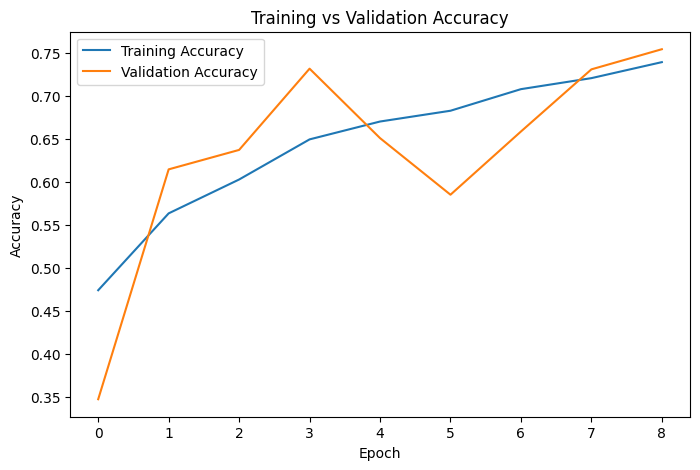

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

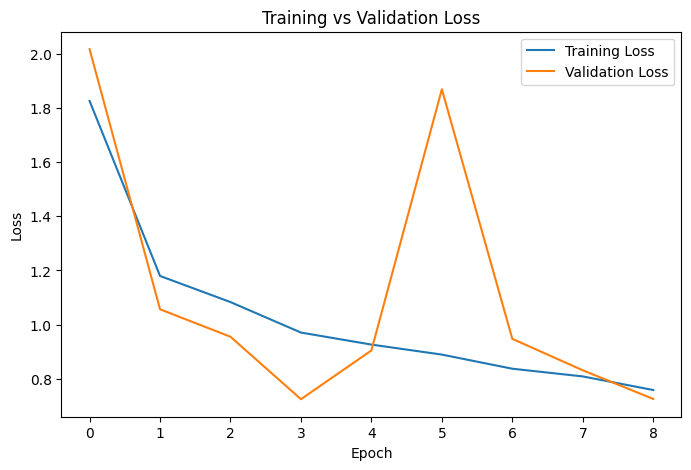

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = baseline_model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7353 - loss: 0.7420
Test Accuracy: 0.7353333234786987


In [ ]:
y_true = []
y_pred = []
for images, labels in test_ds:
    predictions = baseline_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))
y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
print(classification_report(y_true,y_pred,target_names=classes))

              precision    recall  f1-score   support

   buildings       0.66      0.72      0.69       437
      forest       0.91      0.90      0.90       474
     glacier       0.66      0.74      0.70       553
    mountain       0.68      0.73      0.70       525
         sea       0.77      0.56      0.65       510
      street       0.78      0.77      0.77       501

    accuracy                           0.74      3000
   macro avg       0.74      0.74      0.74      3000
weighted avg       0.74      0.74      0.73      3000



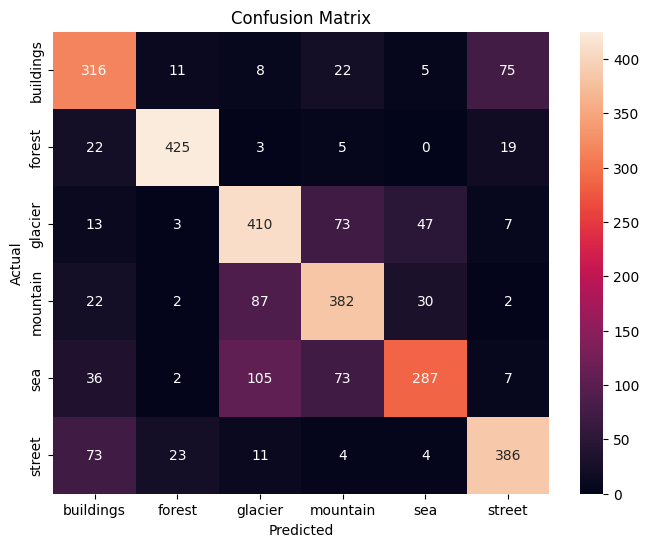

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=classes,yticklabels=classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(150, 150, 3),include_top=False,weights="imagenet")
base_model.trainable = False

/tmp/ipykernel_4649/520114949.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=(150, 150, 3),include_top=False,weights="imagenet")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
transfer_model = keras.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),\
    layers.Dense(6, activation="softmax")
])
transfer_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"])

In [ ]:
transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping])

Epoch 1/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 54s 98ms/step - accuracy: 0.5904 - loss: 1.1009 - val_accuracy: 0.8086 - val_loss: 0.5366
Epoch 2/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.7985 - loss: 0.5476 - val_accuracy: 0.8490 - val_loss: 0.4075
Epoch 3/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.8370 - loss: 0.4440 - val_accuracy: 0.8652 - val_loss: 0.3658
Epoch 4/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.8513 - loss: 0.4038 - val_accuracy: 0.8692 - val_loss: 0.3448
Epoch 5/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.8642 - loss: 0.3725 - val_accuracy: 0.8761 - val_loss: 0.3293
Epoch 6/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.8742 - loss: 0.3483 - val_accuracy: 0.8801 - val_loss: 0.3202
Epoch 7/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8776 - loss: 0.3385 - val_accuracy: 0.8857 - val_loss: 0.3111
Epoch 8/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.8813 - loss: 0.3287 - val_ac

In [ ]:
transfer_test_loss, transfer_test_accuracy = transfer_model.evaluate(test_ds)

print("Transfer Learning Test Accuracy:", transfer_test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.8997 - loss: 0.2751
Transfer Learning Test Accuracy: 0.8996666669845581
